# **KatoNice AI - Supply Chain Intelligence**

# **Latar Belakang**
Ketahanan pangan dipengaruhi oleh faktor lingkungan, produksi, distribusi, dan permintaan. Ketidakseimbangan supply-demand menyebabkan fluktuasi harga yang berdampak pada petani dan konsumen.

# **Tujuan**
- Menganalisis faktor yang mempengaruhi harga pangan
- Mengidentifikasi supply-demand mismatch
- Membangun model prediksi harga berbasis AI
- Memberikan insight strategis untuk stabilisasi harga

# IMPORT **LIBRARY**



In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib

# **LOAD DATA**

In [82]:
df_raw = pd.read_csv('/content/katonice_dataset_realistic_raw.csv')
df_clean = pd.read_csv('/content/katonice_dataset_clean.csv')

print("RAW:", df_raw.shape)
print("CLEAN:", df_clean.shape)

df_raw.head()

RAW: (1212, 10)
CLEAN: (1188, 11)


,lokasi,komoditas,tanggal,suhu_c,curah_hujan_mm,ph_tanah,produksi_kg,permintaan_kg,harga_per_kg,distribusi_jam
0,Malang,Padi,2026-04-03,30.1,1.9,6.26,5642,4962,8742,4
1,Semarang,Padi,2026-01-24,28.0,5.8,6.55,5035,5584,19822,4
2,Semarang,Cabai,2026-02-18,24.1,8.0,6.45,950,409,35268,7
3,Semarang,Cabai,2026-01-03,29.8,9.2,6.44,991,1038,36564,5
4,Malang,Padi,2026-02-22,27.5,1.1,6.69,5474,4852,11641,4


# **EDA (DATA UNDERSTANDING)\**

Dataset awal mengandung beberapa permasalahan seperti missing value, duplikasi, dan anomali yang merepresentasikan kondisi data dunia nyata.

In [86]:
print("Missing Value:\n", df_raw.isnull().sum())
print("\nDuplicate:", df_raw.duplicated().sum())
print("\nAnomali (produksi > 10000):", (df_raw['produksi_kg'] > 10000).sum())

Missing Value:
 lokasi             0
komoditas          0
tanggal            0
suhu_c            24
curah_hujan_mm    24
ph_tanah          24
produksi_kg        0
permintaan_kg      0
harga_per_kg       0
distribusi_jam     0
dtype: int64

Duplicate: 12

Anomali (produksi > 10000): 12


## **Data Cleaning**

Dilakukan untuk:
- Mengatasi missing value
- Menghapus data duplikat
- Menghilangkan anomali ekstrem

Tujuan: meningkatkan kualitas data agar model lebih akurat

In [87]:
df = df_raw.copy()

# Handle missing value
df.fillna(df.median(numeric_only=True), inplace=True)

# Drop duplicate
df.drop_duplicates(inplace=True)

# Filter anomali
df = df[df['produksi_kg'] < 10000]

print("After cleaning:", df.shape)

After cleaning: (1188, 10)


# **DATA COMPARISION**

In [62]:
print("Sebelum:", df_raw.shape)
print("Sesudah:", df.shape)

Sebelum: (1212, 10)
Sesudah: (1188, 10)


# **FEATURE ENGINEERING**

Membuat fitur "gap" sebagai selisih antara produksi dan permintaan.


In [88]:
# Gap supply-demand
df['gap'] = df['produksi_kg'] - df['permintaan_kg']

# Ekstrak bulan dari tanggal
df['bulan'] = pd.to_datetime(df['tanggal']).dt.month

# Drop tanggal (biar ga rusak model & heatmap)
df.drop(columns=['tanggal'], inplace=True)

df.head()

,lokasi,komoditas,suhu_c,curah_hujan_mm,ph_tanah,produksi_kg,permintaan_kg,harga_per_kg,distribusi_jam,gap,bulan
0,Malang,Padi,30.1,1.9,6.26,5642,4962,8742,4,680,4
1,Semarang,Padi,28.0,5.8,6.55,5035,5584,19822,4,-549,1
2,Semarang,Cabai,24.1,8.0,6.45,950,409,35268,7,541,2
3,Semarang,Cabai,29.8,9.2,6.44,991,1038,36564,5,-47,1
4,Malang,Padi,27.5,1.1,6.69,5474,4852,11641,4,622,2


# **VISUALISASI**

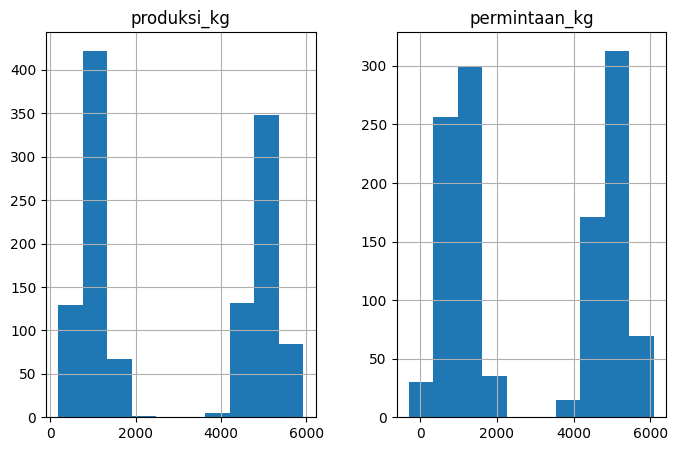

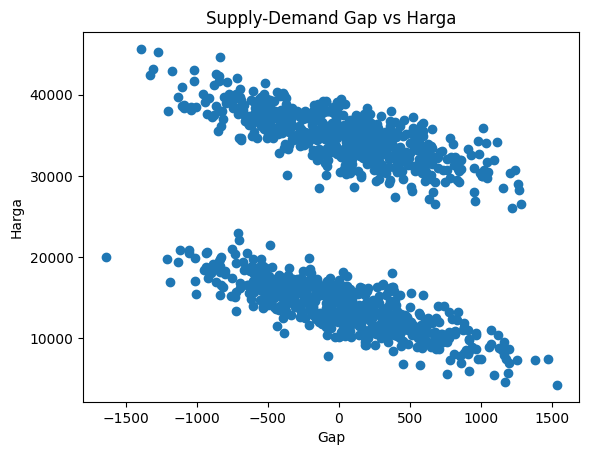

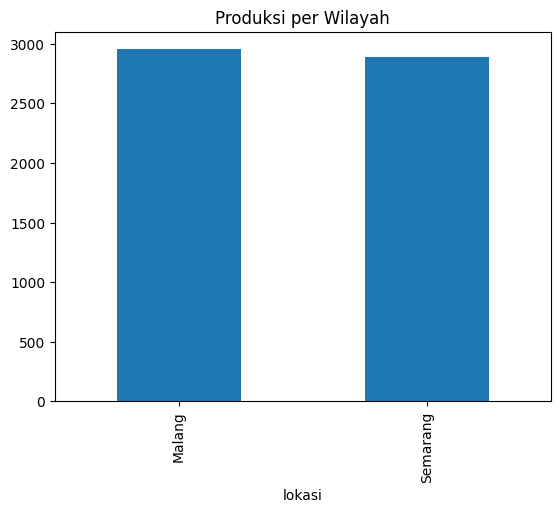

In [64]:
# Histogram produksi vs permintaan
df[['produksi_kg','permintaan_kg']].hist(figsize=(8,5))
plt.show()

# Scatter gap vs harga
plt.scatter(df['gap'], df['harga_per_kg'])
plt.xlabel("Gap")
plt.ylabel("Harga")
plt.title("Supply-Demand Gap vs Harga")
plt.show()

# Produksi per wilayah
df.groupby('lokasi')['produksi_kg'].mean().plot(kind='bar')
plt.title("Produksi per Wilayah")
plt.show()

# **CORRELATION ANALYSIS**

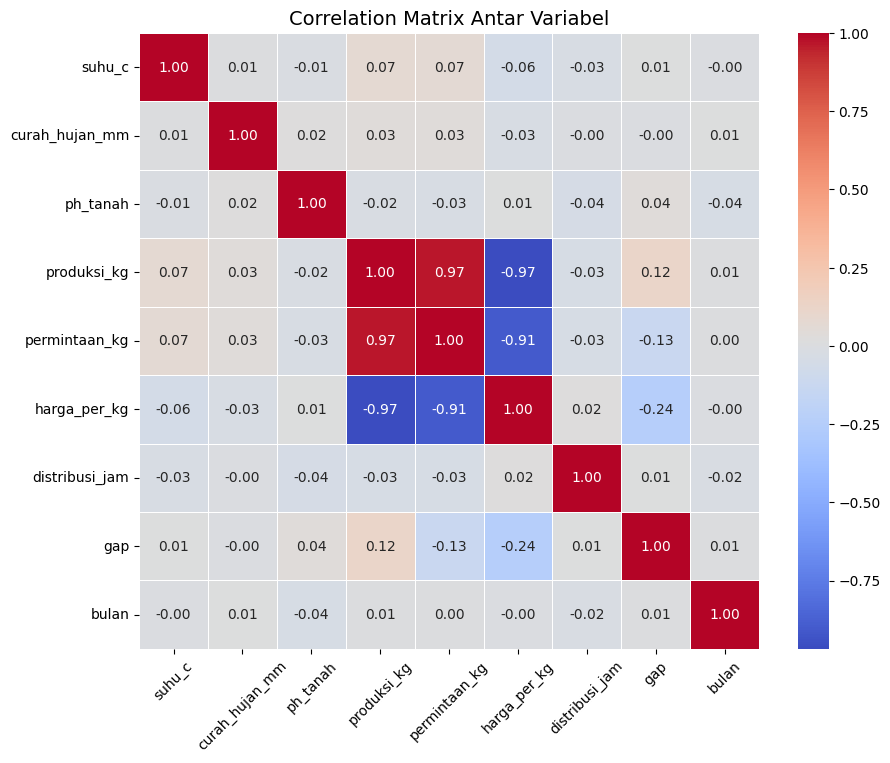

In [89]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Antar Variabel", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

# **PREPROCESSING (ENCODING)**

In [66]:
df = pd.get_dummies(df, drop_first=True)

# **DATA SPLIT**

In [68]:
X = df.drop(['harga_per_kg'], axis=1)
y = df['harga_per_kg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **DATA PREPARATION**

In [90]:
X = df.drop(['harga_per_kg'], axis=1)
y = df['harga_per_kg']

# Encoding kategori
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **MODEL TRAINING**

In [91]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAE:", mae)

RMSE: 2138.916711595091
R2 Score: 0.9621938932562901
MAE: 1685.1940756302522


# **VISUAL EVALUASI**

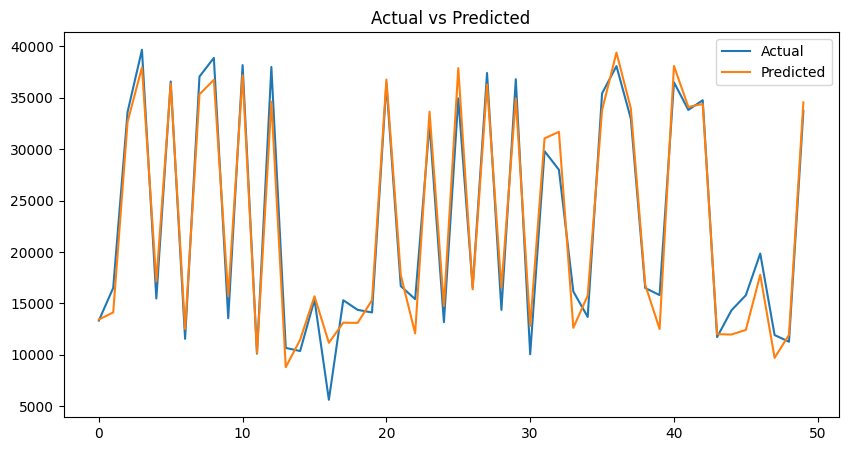

In [92]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")

plt.show()

# **MODEL COMPARISON**

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'RMSE': [rmse_rf, rmse_lr],
    'R2': [r2_rf, r2_lr]
})

comparison

,Model,RMSE,R2
0,Random Forest,2166.877406,0.961199
1,Linear Regression,1998.017885,0.967011


# **FEATURE IMPORTANCE**

In [94]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance.head(10)

,feature,importance
9,komoditas_Padi,0.349143
3,produksi_kg,0.335013
4,permintaan_kg,0.243275
6,gap,0.055377
1,curah_hujan_mm,0.004828
2,ph_tanah,0.004652
0,suhu_c,0.004249
5,distribusi_jam,0.001557
7,bulan,0.001269
8,lokasi_Semarang,0.000637


# SIMULASI **PREDIKSI**

In [95]:
sample = X_test.iloc[[0]]
pred = model.predict(sample)

print("Prediksi Harga:", int(pred[0]))

Prediksi Harga: 13429


# **SAVE MODEL**

In [96]:
joblib.dump(model, 'model.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!


# **LOAD MODEL**

In [75]:
loaded_model = joblib.load('model.pkl')
pred2 = loaded_model.predict(sample)

print("Prediksi dari model file:", int(pred2[0]))

Prediksi dari model file: 13491


# **Pipeline Sistem**

1. Data dikumpulkan (cuaca, produksi, permintaan)
2. Data dibersihkan & diproses
3. Model dilatih
4. Model disimpan (model.pkl)
5. Model digunakan untuk prediksi real-time

# **Data Pipeline Story**

1. Raw dataset digunakan untuk melihat kondisi data asli
2. Data dibersihkan (cleaning)
3. Feature engineering dilakukan (gap)
4. Model dilatih menggunakan data bersih

# **Insight data-driven**

1. Ketika gap negatif besar (permintaan > produksi), harga meningkat signifikan
2. Produksi tinggi tidak menjamin harga stabil jika distribusi tidak optimal
3. Wilayah dengan distribusi cepat cenderung memiliki harga lebih stabil
4. Faktor lingkungan mempengaruhi produksi secara tidak langsung

# **Insight (Manual Analysis)**

1. Supply-demand gap merupakan faktor paling berpengaruh terhadap harga pangan.
2. Ketika permintaan lebih tinggi dibanding produksi, harga meningkat signifikan.
3. Distribusi logistik (durasi pengiriman) berkontribusi terhadap kenaikan harga.
4. Variasi produksi antar wilayah menunjukkan ketidakseimbangan distribusi.
5. Faktor lingkungan seperti suhu dan curah hujan mempengaruhi hasil produksi.

# **Insight Strategis**

1. Ketidak seimbangan supply-demand menyebabkan fluktuasi harga
2. Distribusi yang tidak efisien meningkatkan biaya
3. Faktor lingkungan mempengaruhi produksi
4. Sistem prediksi dapat membantu stabilisasi harga

# **Interpretasi Model**

- Gap supply-demand merupakan faktor utama yang mempengaruhi harga
- Permintaan memiliki pengaruh besar terhadap kenaikan harga
- Distribusi dan faktor lingkungan memperkuat dampak tersebut

# **Implementasi Azure**

Solusi ini dapat diimplementasikan menggunakan:

1. Azure Machine Learning  
   - Training dan deployment model  
   - Monitoring performa model  

2. Azure Blob Storage  
   - Penyimpanan dataset  

3. Azure App Service  
   - API prediksi harga  

4. Azure Functions  
   - Prediksi real-time berbasis event  

Dengan ini, sistem dapat berjalan secara real-time dan scalable.

# **Kesimpulan**

Model berhasil memprediksi harga pangan dengan akurasi tinggi.
Faktor utama yang mempengaruhi harga adalah supply-demand gap.

Solusi ini dapat digunakan untuk:
- Stabilitas harga pangan
- Pengambilan keputusan distribusi
- Monitoring pasar secara real-time